In [2]:
import pandas as pd

In [4]:
csv_path = r"C:\Users\user\Desktop\div\data\files\car-sales-extended-missing-data.csv"
df = pd.read_csv(csv_path)
df

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


In [23]:
df_grouped = df.groupby(["Make", 'Colour'])['Price'].mean()
df_t = df_grouped.to_frame().transpose()
df_t

Make        BMW                                                          \
Colour    Black          Blue         Green           Red         White   
Price   24706.0  29058.103448  18128.666667  21891.363636  28375.470588   

Make           Honda                                                     \
Colour         Black          Blue         Green      Red         White   
Price   14067.925926  14280.460674  17320.444444  15375.1  14380.528302   

Make          Nissan                                                   \
Colour         Black          Blue       Green      Red         White   
Price   12798.692308  14032.925926  12509.5625  13370.0  14312.070423   

Make         Toyota                                                    
Colour        Black          Blue    Green          Red         White  
Price   17767.27027  15480.943396  12994.7  14218.90625  16397.748148

In [26]:
df_t.droplevel(0, axis=1)

Colour,Black,Blue,Green,Red,White,Black,Blue,Green,Red,White,Black,Blue,Green,Red,White,Black,Blue,Green,Red,White
Price,24706.0,29058.103448,18128.666667,21891.363636,28375.470588,14067.925926,14280.460674,17320.444444,15375.1,14380.528302,12798.692308,14032.925926,12509.5625,13370.0,14312.070423,17767.27027,15480.943396,12994.7,14218.90625,16397.748148


In [18]:
df_grouped.droplevel(level=01, axis='rows')

SyntaxError: leading zeros in decimal integer literals are not permitted; use an 0o prefix for octal integers (2865241129.py, line 1)

In [29]:
df_grouped

Make    Colour
BMW     Black     24706.000000
        Blue      29058.103448
        Green     18128.666667
        Red       21891.363636
        White     28375.470588
Honda   Black     14067.925926
        Blue      14280.460674
        Green     17320.444444
        Red       15375.100000
        White     14380.528302
Nissan  Black     12798.692308
        Blue      14032.925926
        Green     12509.562500
        Red       13370.000000
        White     14312.070423
Toyota  Black     17767.270270
        Blue      15480.943396
        Green     12994.700000
        Red       14218.906250
        White     16397.748148
Name: Price, dtype: float64

In [42]:
df_grouped.xs('Red', axis='rows', level='Colour', drop_level=False)

Make    Colour
BMW     Red       21891.363636
Honda   Red       15375.100000
Nissan  Red       13370.000000
Toyota  Red       14218.906250
Name: Price, dtype: float64

In [47]:
df.groupby('Make').agg({
	'Odometer (KM)' : 'mean',
	'Doors' : 'max',
})

,Odometer (KM),Doors
Make,,
BMW,127491.439560,5.0
Honda,125233.374101,4.0
Nissan,136809.029070,4.0
Toyota,135942.582873,4.0


In [49]:
df.head(3)

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0


In [51]:
def f(s: pd.Series):
	return s.mean() - s.min()
	
df.groupby('Make')[['Odometer (KM)']].agg(f)

,Odometer (KM)
Make,
BMW,116442.439560
Honda,114280.374101
Nissan,126661.029070
Toyota,125725.582873


In [54]:
df.head(2)

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0


In [55]:
df.groupby("Make")['Odometer (KM)'].mean()

Make
BMW       127491.439560
Honda     125233.374101
Nissan    136809.029070
Toyota    135942.582873
Name: Odometer (KM), dtype: float64

In [56]:
35431.0 - 125233.374101

-89802.374101

In [57]:
def f(x: pd.Series):
	return x - x.mean()

df.groupby('Make')[['Odometer (KM)']].transform(f)

,Odometer (KM)
0,-89802.374101
1,65222.560440
2,-40519.374101
3,18422.417127
4,44767.970930
...,...
995,-100122.582873
996,NaN
997,-70205.029070
998,90649.625899


In [62]:
def f(x: pd.DataFrame):
	ort_group = x['Odometer (KM)'].mean()
	ort_total = df['Odometer (KM)'].mean()
	return ort_group < ort_total

df.groupby('Make')[['Make', 'Odometer (KM)']].filter(f)

,Make,Odometer (KM)
0,Honda,35431.0
1,BMW,192714.0
2,Honda,84714.0
5,Honda,42652.0
7,Honda,NaN
...,...,...
987,Honda,215235.0
991,Honda,235985.0
992,Honda,54721.0
994,BMW,163322.0


In [ ]:
df.groupby('Make')[['Make', 'Odometer (KM)']].apply

In [ ]:
def f(x):
	if x.name =='Make':
		return x.str[0]
	return x

df.apply(f)

,Make,Colour,Odometer (KM),Doors,Price
0,H,White,35431.0,4.0,15323.0
1,B,Blue,192714.0,5.0,19943.0
2,H,White,84714.0,4.0,28343.0
3,T,White,154365.0,4.0,13434.0
4,N,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,T,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,N,Blue,66604.0,4.0,31570.0
998,H,White,215883.0,4.0,4001.0


In [77]:
'salam necesen'[::3]

'sanen'

In [79]:
df['Make'].str[-1]

0        a
1        W
2        a
3        a
4        n
      ... 
995      a
996    NaN
997      n
998      a
999      a
Name: Make, Length: 1000, dtype: str

In [80]:
%pip install yfinance

  Using cached websockets-16.0-cp311-cp311-win_amd64.whl.metadata (7.0 kB)
  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/1.7 MB ? eta -:--:--
   ------------ --------------------------- 0.5/1.7 MB 2.4 MB/s eta 0:00:01
   ------------------------- -------------- 1.0/1.7 MB 2.5 MB/s eta 0:00:01
   ---------------------------------------- 1.7/1.7 MB 3.0 MB/s  0:00:00
Using cached websockets-16.0-cp311-cp311-win_amd64.whl (178 kB)
Using cached mdurl-0.1.2-py3-none-any.whl (10.0 kB)

   ----------------------------------------  0/10 [pytz]
   ----------------------------------------  0/10 [pytz]
   ----------------------------------------  0/10 [pytz]
   ----------------------------------------  0/10 [pytz]
   ----------------------------------------  0/10 [pytz]
   ----------------------------------------  0/10 [pytz]
   ----------------------------------------  0/10 [pytz]
   ----------------------------------------  0/10 [py

In [1]:
import yfinance as yf

In [5]:
df = yf.download(
	['GOOG'], 
	start='2010-01-01', 
	end='2025-12-31'
)

[*********************100%***********************]  1 of 1 completed


In [8]:
df = df.droplevel(1, axis='columns')
df

Price,Close,High,Low,Open,Volume
Date,,,,,
2010-01-04,15.483122,15.551304,15.421115,15.488062,78541293
2010-01-05,15.414941,15.510050,15.354416,15.493745,120638494
2010-01-06,15.026349,15.461136,14.979412,15.461136,159744526
2010-01-07,14.676543,15.069335,14.640723,15.054512,257533695
2010-01-08,14.872199,14.902584,14.553273,14.624666,189680313
...,...,...,...,...,...
2025-12-23,315.457764,316.077322,310.531242,310.915980,13961400
2025-12-24,315.447784,316.067343,313.099433,315.927427,6138200
2025-12-26,314.738251,316.337130,313.499133,315.697597,6730900


In [16]:
import datetime

In [33]:
gun1 = datetime.date(year=2020, month=10, day=3)
gun1

datetime.date(2020, 10, 3)

In [22]:
bugun = datetime.date.today()
bugun

datetime.date(2026, 6, 4)

In [29]:
bugun.strftime('%m/%d/%Y')

'06/04/2026'

In [ ]:
df.reset_index()

Price,Date,Close,High,Low,Open,Volume
0,2010-01-04,15.483122,15.551304,15.421115,15.488062,78541293
1,2010-01-05,15.414941,15.510050,15.354416,15.493745,120638494
2,2010-01-06,15.026349,15.461136,14.979412,15.461136,159744526
3,2010-01-07,14.676543,15.069335,14.640723,15.054512,257533695
4,2010-01-08,14.872199,14.902584,14.553273,14.624666,189680313
...,...,...,...,...,...,...
4018,2025-12-23,315.457764,316.077322,310.531242,310.915980,13961400
4019,2025-12-24,315.447784,316.067343,313.099433,315.927427,6138200
4020,2025-12-26,314.738251,316.337130,313.499133,315.697597,6730900
4021,2025-12-29,314.168701,314.748279,311.680433,312.599799,12317700


In [69]:
df.loc['2015-01', 'Close'].mean()

np.float64(25.34268913269043)

In [74]:
df_monthly = df.loc['2015':'2020', 'Close'].resample('MS').mean()
df_monthly

Date
2015-01-01    25.342689
2015-02-01    26.607509
2015-03-01    27.681927
2015-04-01    26.745643
2015-05-01    26.544026
                ...    
2020-08-01    76.667800
2020-09-01    75.309406
2020-10-01    76.711612
2020-11-01    86.705579
2020-12-01    87.892317
Freq: MS, Name: Close, Length: 72, dtype: float64

In [80]:
df_monthly.shift(-12) - df_monthly

Date
2015-01-01    10.289561
2015-02-01     8.240838
2015-03-01     8.374891
2015-04-01     9.796042
2015-05-01     8.775149
                ...    
2020-08-01          NaN
2020-09-01          NaN
2020-10-01          NaN
2020-11-01          NaN
2020-12-01          NaN
Freq: MS, Name: Close, Length: 72, dtype: float64

In [82]:
df_monthly.diff(-12)

Date
2015-01-01   -10.289561
2015-02-01    -8.240838
2015-03-01    -8.374891
2015-04-01    -9.796042
2015-05-01    -8.775149
                ...    
2020-08-01          NaN
2020-09-01          NaN
2020-10-01          NaN
2020-11-01          NaN
2020-12-01          NaN
Freq: MS, Name: Close, Length: 72, dtype: float64

<Axes: xlabel='Date'>

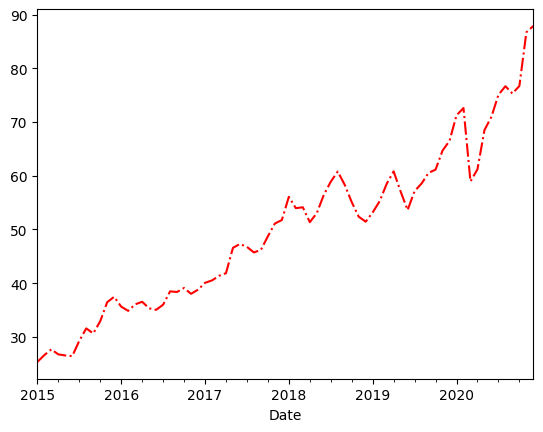

In [94]:
df_monthly.plot(color='red', linestyle='-.')

In [85]:
import matplotlib.pyplot as plt

In [ ]:
plt.plot()